In [1]:
%load_ext autoreload
%autoreload 2

# Introduction to VoxelMorph (PyTorch)

[Adrian Dalca](http://adalca.mit.edu) and Andrew Hoopes

Introductory slides for this tutorial are [here](https://github.com/learn2reg/tutorials2019/blob/master/slides/Learn2reg_tutorial_unsupervided_AdrianDalca.pdf).

This is a short tutorial to get you started with VoxelMorph in PyTorch: demonstrating deep-learning based registration.

### Outline
- **Core concepts with MNIST**
We will first learn to deal with data, building a model, training, registration and generalization
- **More realistic complexity: Brain MRI (2D slices)**
We will then show how these models work for 2d slices of brain scans, presenting a more complex scenario
- **Realistic 3D Brain MRI**
We will illustrate full 3D registration
- **Advances topics**
Finally, we close with more advanced topics, including diffeomorphisms and fine-tuning deformations

Throughout this tutorial we assume that the images have been rigidly aligned in a (roughly) similar space.
Rigid alignment is also possible with VoxelMorph, but it's not our focus here.  A separate tutorial is being designed for that

### References
[VoxelMorph at TMI](https://arxiv.org/abs/1809.05231)

[Diffeomorphic VoxelMorph at MedIA](https://arxiv.org/abs/1903.03545)

[Neurite Library](https://github.com/adalca/neuron) - [CVPR](http://arxiv.org/abs/1903.03148)

---

# Preamble
## Setup of environment

In [ ]:
# Install voxelmorph from the github repository. Not yet on pypi.
!pip install git+https://github.com/voxelmorph/voxelmorph.git

In [74]:
# Standard libra?ry imports
import os
import sys

# Third-party imports
import numpy as np
import torch
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt

print(f'PyTorch version: {torch.__version__}')

PyTorch version: 2.8.0


Import dependencies from dalcalab

- [voxelmorph](http://voxelmorph.mit.edu) is a deep-learning based registration library

- [neurite](https://github.com/adalca/neurite) is a library for medical image analysis with tensorflow  

In [99]:
# Local imports - PyTorch version of voxelmorph
import voxelmorph as vxm
import neurite as ne

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


---

# Data

We're going to start by registering 2D MNIST digits, and then move on to medical data later. If the data is small (like 2D MNIST), you can often load it in memory, which enables for faster training and testing. If the data is large (large 3D scans), we will likely need to load the scans on demand. More on this later.

First, we're going to **load the data**. We'll use torchvision to load MNIST data.

In [100]:
# Load MNIST data using torchvision
from torchvision import datasets, transforms

# Define transform to convert images to tensors
transform = transforms.Compose([
    transforms.ToTensor(),
])

# Load MNIST dataset
mnist_train = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
mnist_test = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Extract only digit 5
digit_sel = 5

# Filter for digit 5 only
train_indices = [i for i, (_, label) in enumerate(mnist_train) if label == digit_sel]
test_indices = [i for i, (_, label) in enumerate(mnist_test) if label == digit_sel]

# Extract data for digit 5
x_train_load = torch.stack([mnist_train[i][0].squeeze() for i in train_indices])
y_train_load = torch.tensor([mnist_train[i][1] for i in train_indices])
x_test_load = torch.stack([mnist_test[i][0].squeeze() for i in test_indices])
y_test_load = torch.tensor([mnist_test[i][1] for i in test_indices])

print(f'shape of x_train: {x_train_load.shape}, y_train: {y_train_load.shape}')

shape of x_train: torch.Size([5421, 28, 28]), y_train: torch.Size([5421])


**ML detour**: separating your data in *only* train/test **often leads to problems**
You wouldn't want to iteratively (A) build a model, (B) train on training data, and (C) test on test data
Doing so will **overfit to you test set** (because you will have adapted your algorithm to your test data). It's a common mistake in ML submissions.

We will split the 'training' into 'train/validate' data, and keep the test set for later
And will only look at the test data at the very end (once we're ready to submit the paper!)

In [101]:
nb_val = 1000  # keep 1,000 subjects for validation
x_val = x_train_load[-nb_val:]
y_val = y_train_load[-nb_val:]
x_train = x_train_load[:-nb_val]
y_train = y_train_load[:-nb_val]
x_test = x_test_load
y_test = y_test_load

### Visualize Data

When we are done loading, it's always great to visualize the data
Here, we use some tools from a package called `neurite`, which uses matplotlib
You could use matplotlib as well directly, but it would just be a bit messier
and here we want to illustrate the main concepts.

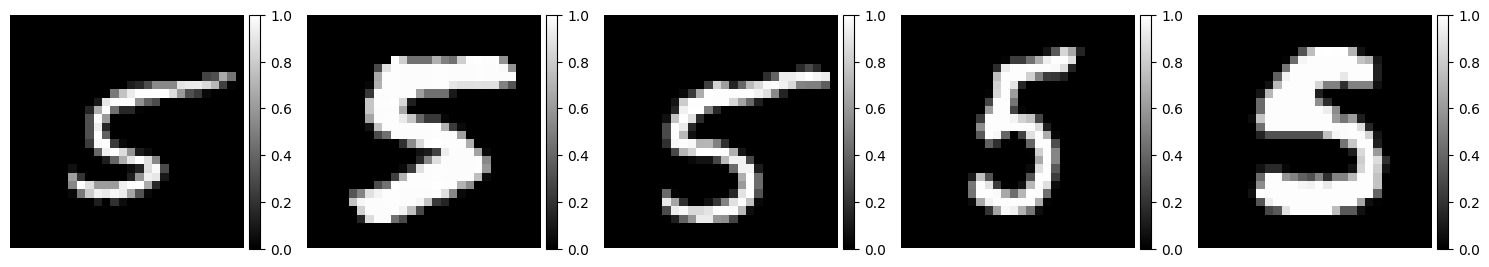

(<Figure size 1500x300 with 10 Axes>,
 [array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object)])

In [102]:
nb_vis = 5

# choose nb_vis sample indexes
idx = np.random.choice(x_train.shape[0], nb_vis, replace=False)
example_digits = [x_train[i].numpy() for i in idx]

# plot
ne.plot.slices(example_digits, cmaps=['gray'], do_colorbars=True)

Looks good!

The data is already in [0, 1] range from torchvision's ToTensor transform, so we don't need to normalize.

In general, you should always plot your data with colorbars, which helps you catch issues before training

In [103]:
# verify
print('training maximum value', x_train.max().item())

training maximum value 1.0


One last change. Later on, we'll see that some of the most popular models like to have inputs that are sized as multiples of 2^N for N being the number of layers. Here, we force our images to be size 32 (2x 2^4).

In [104]:
# Pad from 28x28 to 32x32
import torch.nn.functional as F

x_train = F.pad(x_train, (2, 2, 2, 2), 'constant', 0)
x_val = F.pad(x_val, (2, 2, 2, 2), 'constant', 0)
x_test = F.pad(x_test, (2, 2, 2, 2), 'constant', 0)

# verify
print('shape of training data', x_train.shape)

shape of training data torch.Size([4421, 32, 32])


---

# CNN Model

Given two images (which we call *source* and *target*), our goal is to find the deformation between them. In learning-based methods, we use a network that takes in two images $s$ ("source") and $t$ ("target") (e.g. MNIST digits of size 32x32) and outputs a dense deformation $\phi$ (e.g. size 32x32x2, because at each pixel we want a vector telling us where to go). Intuitively, this deformation $\phi$ gives us the correspondances between the images, and tells us how to move the source image to match up with the target image.

**Note**: Registration also includes (or refers to) affine transforms, but we ignore that here.

The [VoxelMorph](http://voxelmorph.mit.edu) library provides a `VxmPairwise` model class for building dense deformation networks in PyTorch.

In [105]:
# configure model parameters
ndim = 2
spatial_shape = x_train.shape[1:]  # (32, 32)
source_channels = 1
target_channels = 1
out_channels = ndim  # 2 for 2D displacement field

# configure unet features
nb_features = [16, 16, 16, 16, 16]

# build VoxelMorph model
vxm_model = vxm.nn.models.VxmPairwise(
    ndim=ndim,
    source_channels=source_channels,
    target_channels=target_channels,
    spatial_shape=spatial_shape,
    nb_features=nb_features
)

# Move model to device
vxm_model = vxm_model.to(device)

print('Model created successfully')
print(f'Model parameters: {sum(p.numel() for p in vxm_model.parameters())}')

Model created successfully
Model parameters: 60616


### Loss

Given that the displacement $\phi$ is output from the network,
we need to figure out a loss to tell if it makes sense

In a **supervised setting** we would have ground truth deformations $\phi_{gt}$,
and we could use a supervised loss like MSE $= \| \phi - \phi_{gt} \|$

The main idea in **unsupervised registration** is to use loss inspired by classical registration

Without supervision, how do we know this deformation is good?
(1) make sure that $m \circ \phi$ ($m$ warped by $\phi$) is close to $f$
(2) regularize $\phi$ (often meaning make sure it's smooth)

Now that we've learned how to easily build our networks, let's define the actual loss. The way we train neural networks, we need to define losses for our outputs.
The first loss is easy, it's simply MSE between the warped image $m \circ \phi$ and the fixed image $f$.
For the second, we will use a spatial gradient loss of the displacement field $\phi$.
We won't code this from scratch here, but we'll use the `voxelmorph` implementation that includes both L1 and L2 penalties.

In [106]:
# Define loss functions - fixing the overwrite bug
mse_loss = vxm.nn.losses.MSE()
grad_loss = vxm.nn.losses.Grad('l2')

# Loss weights (similar to TensorFlow version)
lambda_param = 0.05
loss_weights = [1, lambda_param]

print(f'MSE loss: {mse_loss}')
print(f'Grad loss: {grad_loss}')
print(f'Loss weights: {loss_weights}')

MSE loss: <voxelmorph.nn.losses.MSE object at 0x12f4cb2f0>
Grad loss: <voxelmorph.nn.losses.Grad object at 0x120e370b0>
Loss weights: [1, 0.05]


# Train Model

To train, we need to make sure the data is in the right format and fed to the model the way we want it. We'll create a PyTorch dataset and dataloader.

In [107]:
class VoxelMorphDataset(Dataset):
    """
    Dataset for VoxelMorph training that generates random pairs of images.
    """

    def __init__(self, x_data, device='cpu'):
        self.x_data = x_data
        self.device = device
        self.vol_shape = x_data.shape[1:]
        self.ndims = len(self.vol_shape)

    def __len__(self):
        return len(self.x_data) * 10  # Artificially increase dataset size

    def __getitem__(self, idx):
        # Select random moving and fixed images
        moving_idx = np.random.randint(0, len(self.x_data))
        fixed_idx = np.random.randint(0, len(self.x_data))

        moving_image = self.x_data[moving_idx].unsqueeze(0).to(self.device)  # Add channel dim
        fixed_image = self.x_data[fixed_idx].unsqueeze(0).to(self.device)   # Add channel dim

        # Create zero displacement field for loss computation
        zero_phi = torch.zeros(self.ndims, *self.vol_shape, device=self.device)

        return {
            'moving': moving_image,
            'fixed': fixed_image,
            'zero_phi': zero_phi
        }

# Create dataset and dataloader
train_dataset = VoxelMorphDataset(x_train, device=device)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)

# Test the dataset
sample = train_dataset[0]
print(f"Moving image shape: {sample['moving'].shape}")
print(f"Fixed image shape: {sample['fixed'].shape}")
print(f"Zero phi shape: {sample['zero_phi'].shape}")

Moving image shape: torch.Size([1, 32, 32])
Fixed image shape: torch.Size([1, 32, 32])
Zero phi shape: torch.Size([2, 32, 32])


Now let's visualize a sample from our dataset

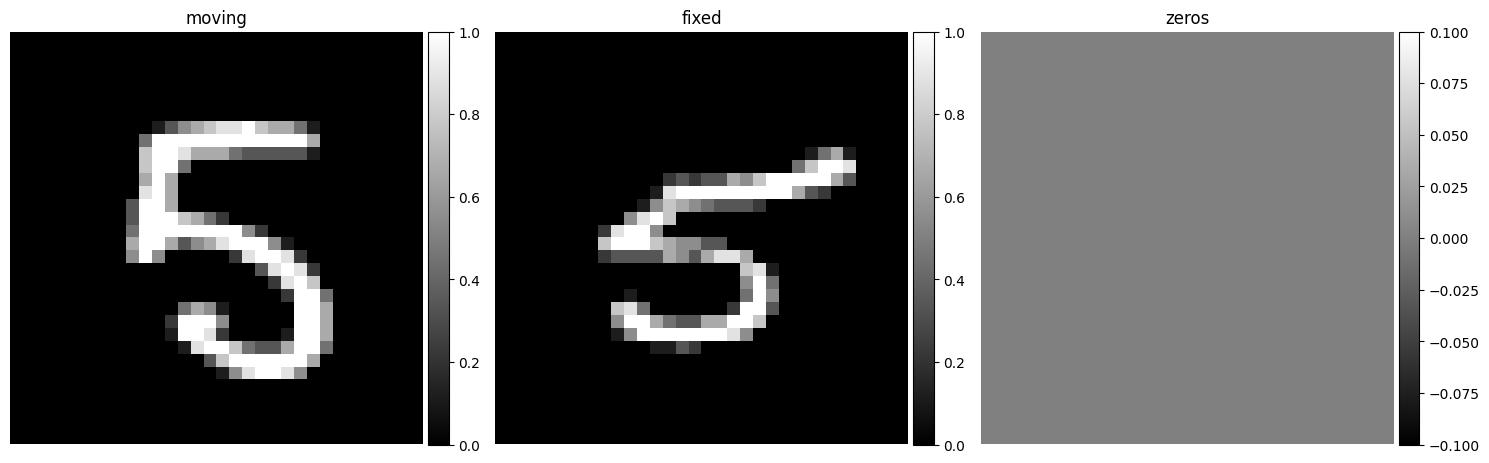

(<Figure size 1500x500 with 6 Axes>,
 [array([<Axes: title={'center': 'moving'}>,
         <Axes: title={'center': 'fixed'}>,
         <Axes: title={'center': 'zeros'}>], dtype=object)])

In [108]:
# Visualize a sample
sample = train_dataset[0]
moving_img = sample['moving'].squeeze().cpu().numpy()
fixed_img = sample['fixed'].squeeze().cpu().numpy()
zeros = torch.zeros_like(sample['fixed']).squeeze().cpu().numpy()

images = [moving_img, fixed_img, zeros]
titles = ['moving', 'fixed', 'zeros']
ne.plot.slices(images, titles=titles, cmaps=['gray'], do_colorbars=True)

In [109]:
# Setup optimizer
optimizer = optim.Adam(vxm_model.parameters(), lr=1e-3)

# Training parameters
nb_epochs = 10
steps_per_epoch = 100

# Training history
train_history = {'loss': [], 'image_loss': [], 'flow_loss': []}

print('Starting training...')

Starting training...


In [110]:
# Training loop with both MSE and Grad losses
vxm_model.train()

for epoch in range(nb_epochs):
    epoch_loss = 0
    epoch_image_loss = 0
    epoch_flow_loss = 0

    for step, batch in enumerate(train_loader):
        if step >= steps_per_epoch:
            break

        optimizer.zero_grad()

        # Get batch data
        moving = batch['moving']
        fixed = batch['fixed']
        zero_phi = batch['zero_phi']

        # Forward pass - get both velocity field and warped image
        velocity, moved = vxm_model(moving, fixed, return_warped=True)

        # Compute losses
        image_loss = mse_loss.loss(fixed, moved)
        
        # Use the mean_loss method to get scalar output for PyTorch backward()
        flow_loss = grad_loss.mean_loss(zero_phi, velocity)

        # Combined loss (matching TensorFlow approach)
        total_loss = loss_weights[0] * image_loss + loss_weights[1] * flow_loss

        # Backward pass
        total_loss.backward()
        optimizer.step()

        # Accumulate losses
        epoch_loss += total_loss.item()
        epoch_image_loss += image_loss.item()
        epoch_flow_loss += flow_loss.item()

    # Average losses for epoch
    avg_loss = epoch_loss / steps_per_epoch
    avg_image_loss = epoch_image_loss / steps_per_epoch
    avg_flow_loss = epoch_flow_loss / steps_per_epoch

    train_history['loss'].append(avg_loss)
    train_history['image_loss'].append(avg_image_loss)
    train_history['flow_loss'].append(avg_flow_loss)

    print(f'Epoch {epoch+1}/{nb_epochs} - Loss: {avg_loss:.4f} - Image Loss: {avg_image_loss:.4f} - Flow Loss: {avg_flow_loss:.4f}')

print('Training completed!')

Epoch 1/10 - Loss: 0.0668 - Image Loss: 0.0659 - Flow Loss: 0.0172
Epoch 2/10 - Loss: 0.0446 - Image Loss: 0.0421 - Flow Loss: 0.0493
Epoch 3/10 - Loss: 0.0366 - Image Loss: 0.0336 - Flow Loss: 0.0602
Epoch 4/10 - Loss: 0.0321 - Image Loss: 0.0289 - Flow Loss: 0.0649
Epoch 5/10 - Loss: 0.0286 - Image Loss: 0.0248 - Flow Loss: 0.0761
Epoch 6/10 - Loss: 0.0265 - Image Loss: 0.0221 - Flow Loss: 0.0870
Epoch 7/10 - Loss: 0.0253 - Image Loss: 0.0207 - Flow Loss: 0.0919
Epoch 8/10 - Loss: 0.0240 - Image Loss: 0.0193 - Flow Loss: 0.0946
Epoch 9/10 - Loss: 0.0232 - Image Loss: 0.0183 - Flow Loss: 0.0972
Epoch 10/10 - Loss: 0.0224 - Image Loss: 0.0176 - Flow Loss: 0.0970
Training completed!


It's always a good idea to visualize the loss, not just read off the numbers. This will give us a better idea of whether it's converged, etc.

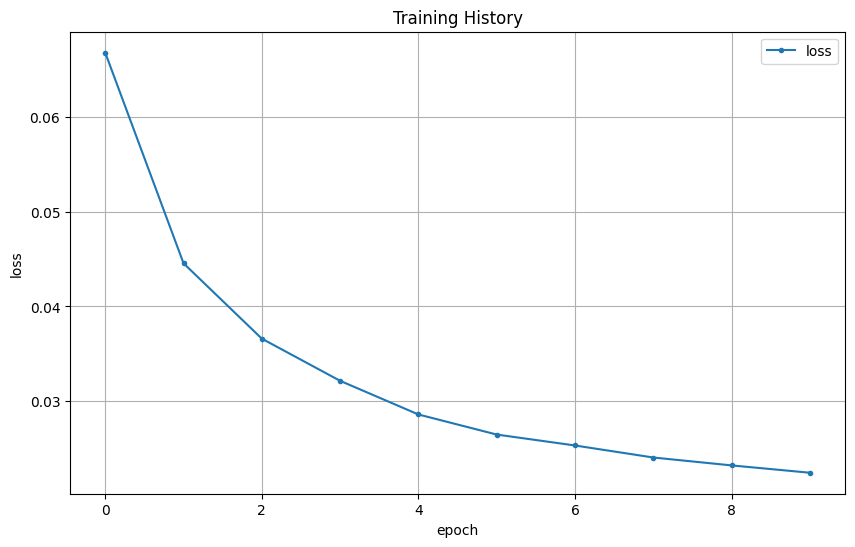

In [113]:
def plot_history(hist, loss_name='loss'):
    """Simple function to plot training history."""
    plt.figure(figsize=(10, 6))
    plt.plot(hist[loss_name], '.-', label=loss_name)
    # if 'image_loss' in hist:
    #     plt.plot(hist['image_loss'], '.-', label='image_loss')
    # if 'flow_loss' in hist:
    #     plt.plot(hist['flow_loss'], '.-', label='flow_loss')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend()
    plt.title('Training History')
    plt.grid(True)
    plt.show()

plot_history(train_history)

Clearly, this is not converged, and you should run it to convergence, but for the purposes of this tutorial, we'll move on.

# Registration

With pair-wise optimization methods (like most classical methods), to register a new pair you would need to optimize a deformation field.

With learning based registration, we simply evaluate the network for a new input pair

In [114]:
# Get validation data for testing
vxm_model.eval()

with torch.no_grad():
    # Get random validation pair
    val_idx1 = np.random.randint(0, len(x_val))
    val_idx2 = np.random.randint(0, len(x_val))

    val_moving = x_val[val_idx1].unsqueeze(0).unsqueeze(0).to(device)  # Add batch and channel dims
    val_fixed = x_val[val_idx2].unsqueeze(0).unsqueeze(0).to(device)   # Add batch and channel dims

    print(f'Validation moving shape: {val_moving.shape}')
    print(f'Validation fixed shape: {val_fixed.shape}')

Validation moving shape: torch.Size([1, 1, 32, 32])
Validation fixed shape: torch.Size([1, 1, 32, 32])


*Registration*: `forward()` essentially executes the network given an input. We can include the `return_warped=True` argument to return the warped image (which uses the `vxm.nn.layers.SpatialTransformer` internally, so we don't need to mess with it).

In [115]:
with torch.no_grad():
    val_velocity, val_moved = vxm_model(val_moving, val_fixed, return_warped=True)

and that's it!

Even though this is on MNIST only, let's see how long this takes

In [116]:
# Time the registration
%timeit vxm_model(val_moving, val_fixed, return_warped=True)

1.13 ms ± 4.7 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


~1 ms per registration is quite fast, even for MNIST. Let's visualize the results.

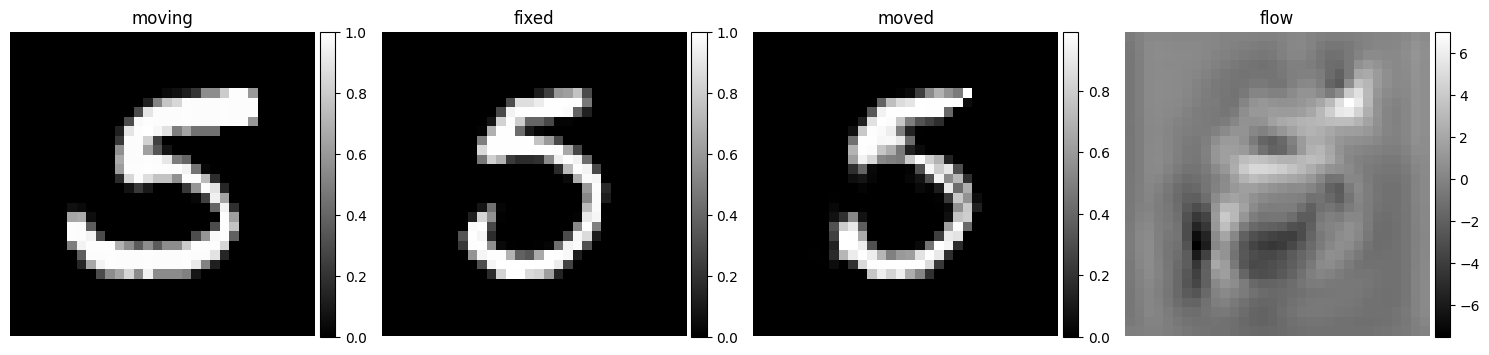

(<Figure size 1500x375 with 8 Axes>,
 [array([<Axes: title={'center': 'moving'}>,
         <Axes: title={'center': 'fixed'}>,
         <Axes: title={'center': 'moved'}>,
         <Axes: title={'center': 'flow'}>], dtype=object)])

In [117]:
# Convert to numpy for visualization
val_moving_np = val_moving.squeeze().cpu().numpy()
val_fixed_np = val_fixed.squeeze().cpu().numpy()
val_moved_np = val_moved.squeeze().cpu().numpy()
val_velocity_np = val_velocity.squeeze().cpu().numpy()

# Visualize
images = [val_moving_np, val_fixed_np, val_moved_np, val_velocity_np.sum(0)]
titles = ['moving', 'fixed', 'moved', 'flow']
ne.plot.slices(images, titles=titles, cmaps=['gray'], do_colorbars=True)

Let's visualize the flow a bit better.

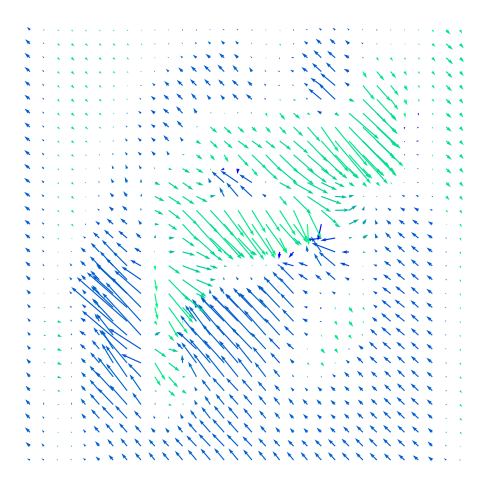

(<Figure size 500x500 with 1 Axes>, [<Axes: >])

In [118]:
# PyTorch velocity field is typically (batch, channels, height, width) where channels are the displacement components
velocity_for_viz = val_velocity_np.transpose(1, 2, 0)  # Convert to (H, W, 2) format
ne.plot.flow([velocity_for_viz], width=5)

# Generalization
How do learning-based methods generalize beyond training distribution ?

An important caveat to learning-based registration is that they will, in general, only register samples from the distribution they've been trained from.

So, what happens if we register two 7's?

In [119]:
# Extract digit 7 data
seven_indices = [i for i, (_, label) in enumerate(mnist_train) if label == 7]
x_sevens = torch.stack([mnist_train[i][0].squeeze() for i in seven_indices[:1000]])
x_sevens = F.pad(x_sevens, (2, 2, 2, 2), 'constant', 0)

# Test on sevens
with torch.no_grad():
    seven_idx1 = np.random.randint(0, len(x_sevens))
    seven_idx2 = np.random.randint(0, len(x_sevens))

    seven_moving = x_sevens[seven_idx1].unsqueeze(0).unsqueeze(0).to(device)
    seven_fixed = x_sevens[seven_idx2].unsqueeze(0).unsqueeze(0).to(device)

    seven_velocity, seven_moved = vxm_model(seven_moving, seven_fixed, return_warped=True)

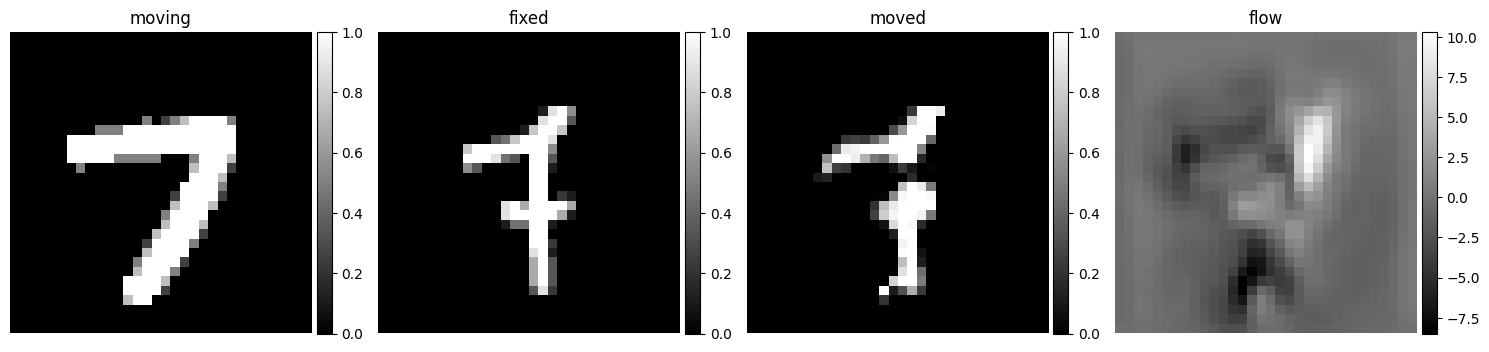

(<Figure size 1500x375 with 8 Axes>,
 [array([<Axes: title={'center': 'moving'}>,
         <Axes: title={'center': 'fixed'}>,
         <Axes: title={'center': 'moved'}>,
         <Axes: title={'center': 'flow'}>], dtype=object)])

In [120]:
# Visualize seven results
seven_moving_np = seven_moving.squeeze().cpu().numpy()
seven_fixed_np = seven_fixed.squeeze().cpu().numpy()
seven_moved_np = seven_moved.squeeze().cpu().numpy()
seven_velocity_np = seven_velocity.squeeze().cpu().numpy()

images = [seven_moving_np, seven_fixed_np, seven_moved_np, seven_velocity_np.sum(0)]
titles = ['moving', 'fixed', 'moved', 'flow']
ne.plot.slices(images, titles=titles, cmaps=['gray'], do_colorbars=True)

Interesting - it still works! So it **generalized beyond what we expected**. Why? Locally, parts of the 7s look similar to the 5s, so the registration algorithm still tries to match local neighborhoods.

Let's try a different variation. What if we just modify the (original) set, but multiplied the intensities by a factor?

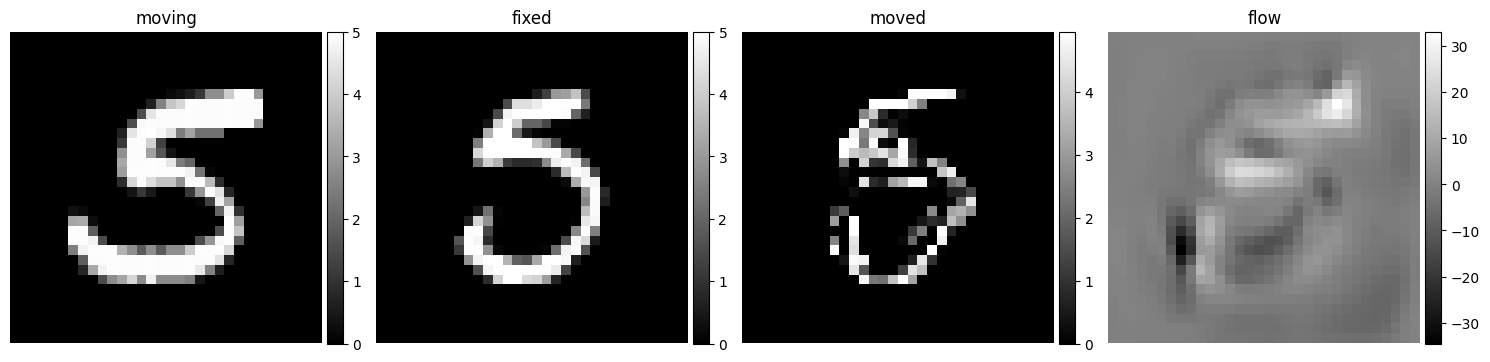

(<Figure size 1500x375 with 8 Axes>,
 [array([<Axes: title={'center': 'moving'}>,
         <Axes: title={'center': 'fixed'}>,
         <Axes: title={'center': 'moved'}>,
         <Axes: title={'center': 'flow'}>], dtype=object)])

In [121]:
factor = 5
with torch.no_grad():
    val_velocity_scaled, val_moved_scaled = vxm_model(val_moving * factor, val_fixed * factor, return_warped=True)

# Visualize
val_moved_scaled_np = val_moved_scaled.squeeze().cpu().numpy()
val_velocity_scaled_np = val_velocity_scaled.squeeze().cpu().numpy()

images = [val_moving_np * factor, val_fixed_np * factor, val_moved_scaled_np, val_velocity_scaled_np.sum(0)]
titles = ['moving', 'fixed', 'moved', 'flow']
ne.plot.slices(images, titles=titles, cmaps=['gray'], do_colorbars=True)

This broke down! Why? In this case, the network has never seen even parts of this image.

Understanding when the network generalizes and when it does not is very important, and still a part of active research.

# Summary

In this PyTorch tutorial, we've demonstrated:
1. Loading and preprocessing MNIST data for registration
2. Building a VoxelMorph registration model using PyTorch
3. Training the model with unsupervised losses (MSE + gradient regularization)
4. Performing registration inference
5. Analyzing model generalization capabilities

The PyTorch implementation provides similar functionality to the TensorFlow version while leveraging PyTorch's ecosystem and GPU acceleration capabilities.

For more complex scenarios like 3D brain MRI registration, the same principles apply but with:
- 3D convolutions instead of 2D
- Different data loading strategies for large volumes
- Potentially different loss functions and training strategies
- Integration with medical imaging libraries like nibabel for NIFTI files